# SVD Baseline Evaluation

Évalue les deux phases du pipeline SVD :
1. **Reconstruction SVD** (`svd_bases.pt`) — erreur de troncature SVD+Laplace vs champ réel
2. **Surrogate SVD** (`svd_surrogates.pt`) — erreur θ→U vs champ réel (métrique corrigée)

La L2rel est toujours calculée vs le **champ réel U**, contrairement au wandb de `train_svd.py` qui mesurait l'erreur vs la reconstruction SVD (biais optimiste).

In [10]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import gc
import re
import time
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from tqdm.auto import tqdm

from laplace_surrogate.models.surrogate_base import FreqSurrogate
from laplace_surrogate.laplace_transform.learnable import LearnableLaplace

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} / {torch.cuda.mem_get_info()[1]/1024**3:.1f} GB')

Device: cuda
  GPU: NVIDIA RTX A5000
  Free: 2.8 / 22.0 GB


## 1. Chargement des données

In [11]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
SVD_BASES_PATH  = '../checkpoints/svd_bases.pt'
SVD_SURR_PATH   = '../checkpoints/svd_surrogates.pt'
CACHE_DIR  = 'cache_svd'
os.makedirs(CACHE_DIR, exist_ok=True)

# Raw field data (mmap)
U_raw = np.load(DATA_PATH, mmap_mode='r')   # (ns, Nt, H, W)
ns, NT_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={NT_full}, {H}×{W}')

# Physical parameters
doe       = np.load(DOE_PATH)
theta_raw = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)  # (ns, 3)

# Split
split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

# SVD checkpoints
bases_ckpt = torch.load(SVD_BASES_PATH,  map_location='cpu', weights_only=False)
surr_ckpt  = torch.load(SVD_SURR_PATH,   map_location='cpu', weights_only=False)

N       = bases_ckpt['N']
NT      = bases_ckpt['NT']
DT      = bases_ckpt['DT']
ALPHA_T = bases_ckpt['ALPHA_T']
LAM     = bases_ckpt['LAM']

# theta normalization (from svd_surrogates.pt)
theta_mean = surr_ckpt['theta_mean'].numpy()   # (3,)
theta_std  = surr_ckpt['theta_std'].numpy()    # (3,)

print(f'N={N}, NT={NT}, DT={DT}')
print(f'Configs in svd_bases:     {[f"K{K}_ksvd{k}_g{g:.3f}" for K,k,g in bases_ckpt["configs"]]}')
print(f'Configs in svd_surrogates: {list(surr_ckpt["models"].keys())}')

Dataset: 8100 sims, Nt=150, 128×128


Train: 6480  Test: 1620
N=128, NT=150, DT=1.0
Configs in svd_bases:     ['K8_ksvd64_g0.010', 'K16_ksvd32_g0.010', 'K16_ksvd64_g0.000', 'K16_ksvd64_g0.001', 'K16_ksvd64_g0.010', 'K16_ksvd128_g0.010', 'K32_ksvd64_g0.010']
Configs in svd_surrogates: ['K8_ksvd64_g0.010', 'K16_ksvd64_g0.000', 'K16_ksvd32_g0.010', 'K16_ksvd64_g0.001', 'K16_ksvd64_g0.010', 'K16_ksvd128_g0.010']


In [12]:
def load_u_batch(idx_list: list) -> np.ndarray:
    """Load a batch of raw U fields as (B, Nt, N, N) float32."""
    out = []
    for i in idx_list:
        u = U_raw[i].astype(np.float32)
        if u.shape[-1] != N:
            u_t = torch.from_numpy(u).unsqueeze(1)
            u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
            u   = u_t.squeeze(1).numpy()
        out.append(u)
    return np.stack(out)   # (B, Nt, N, N)

# Helper: pretty config label
def _label(K, k_svd, g):
    return f'K={K}, ksvd={k_svd}, γ={g}'

def _tag(K, k_svd, g):
    return f'K{K}_ksvd{k_svd}_g{g:.3f}'

sorted_test = sorted(test_idx)

## 2. Reconstruction SVD — Évaluation

Les erreurs de reconstruction (`errors_phys`) dans `svd_bases.pt` sont calculées vs le champ réel U : métrique correcte.

In [13]:
rec_results = {}   # tag → np.array L2rel (%)
freq_results = {}  # tag → (n_test, K) array

for K, k_svd, g in bases_ckpt['configs']:
    tag = _tag(K, k_svd, g)
    ev  = bases_ckpt['eval'][tag]
    rec_results[tag]  = np.array(ev['errors_phys'])
    freq_results[tag] = np.array(ev['freq_errors'])
    l2 = rec_results[tag]
    print(f'{tag:<25}  median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  p90={np.percentile(l2,90):.2f}%')

print(f'\n({len(rec_results)} configs)')

K8_ksvd64_g0.010           median=12.01%  mean=12.97%  p90=17.39%
K16_ksvd32_g0.010          median=11.42%  mean=13.92%  p90=22.99%
K16_ksvd64_g0.000          median=8.42%  mean=9.48%  p90=14.22%
K16_ksvd64_g0.001          median=8.38%  mean=9.47%  p90=14.29%
K16_ksvd64_g0.010          median=8.09%  mean=9.43%  p90=14.67%
K16_ksvd128_g0.010         median=7.04%  mean=7.47%  p90=9.79%
K32_ksvd64_g0.010          median=7.57%  mean=8.86%  p90=15.08%

(7 configs)


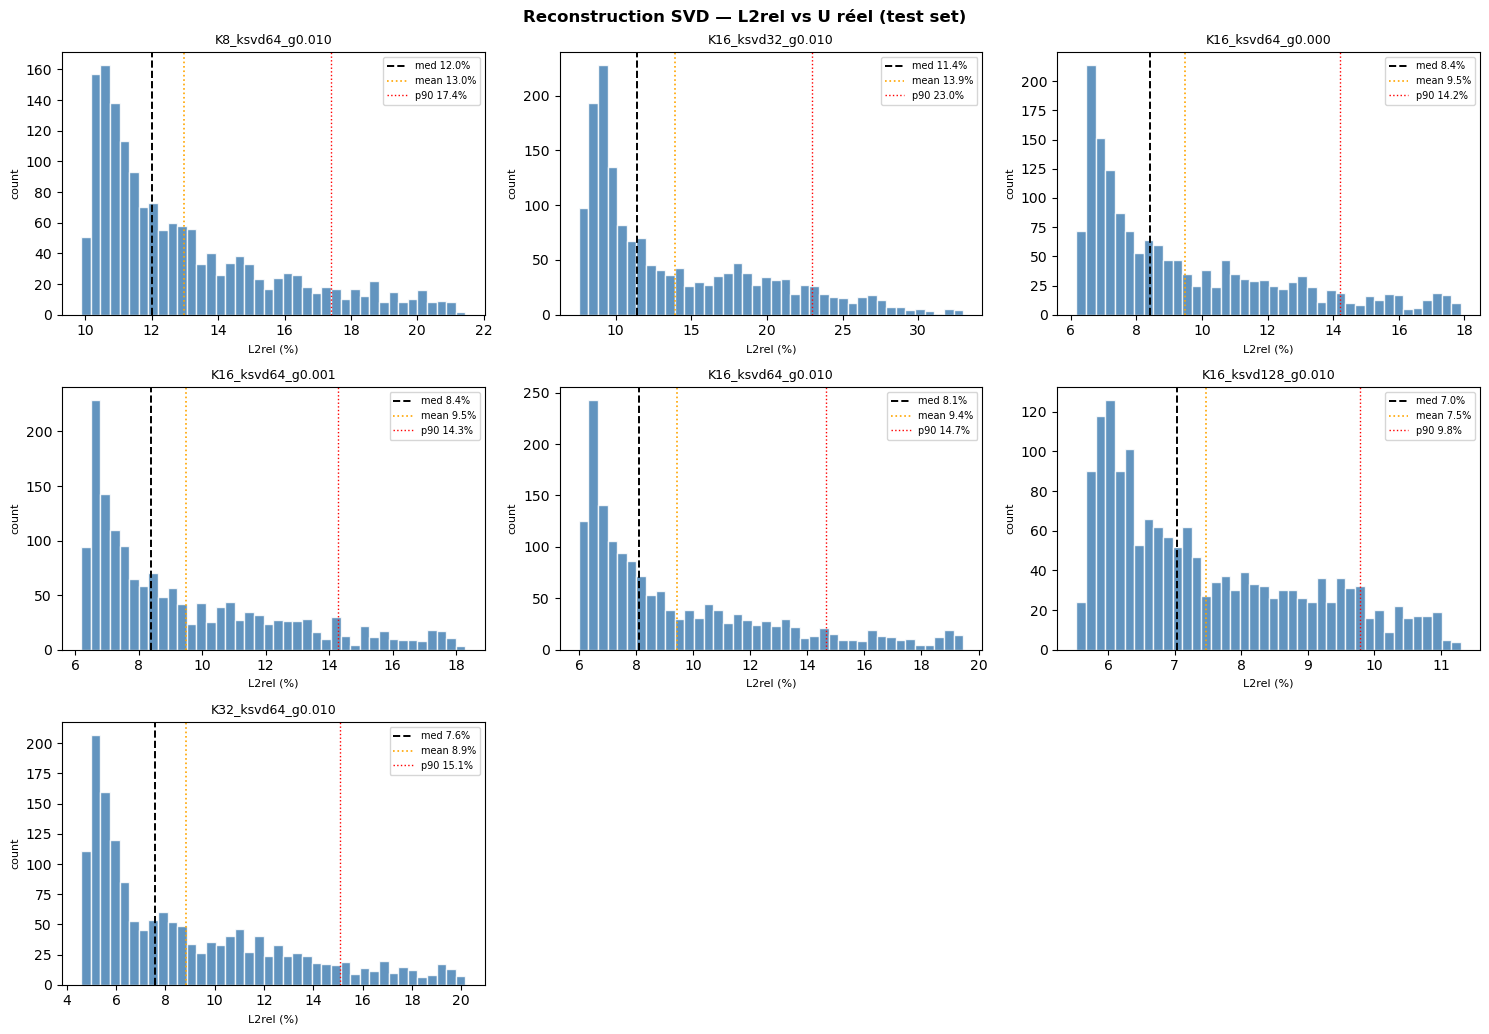

In [14]:
# Histogrammes par config
tags   = list(rec_results.keys())
ncols  = 3
nrows  = (len(tags) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = np.array(axes).flatten()

for ax, tag in zip(axes, tags):
    l2     = rec_results[tag]
    median = np.median(l2)
    ax.hist(l2, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(median,              color='black',  linestyle='--', lw=1.4, label=f'med {median:.1f}%')
    ax.axvline(np.mean(l2),         color='orange', linestyle=':',  lw=1.2, label=f'mean {np.mean(l2):.1f}%')
    ax.axvline(np.percentile(l2,90),color='red',    linestyle=':',  lw=1.0, label=f'p90 {np.percentile(l2,90):.1f}%')
    ax.set_title(tag, fontsize=9)
    ax.set_xlabel('L2rel (%)', fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.legend(fontsize=7)

for ax in axes[len(tags):]:
    ax.set_visible(False)

fig.suptitle('Reconstruction SVD — L2rel vs U réel (test set)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## 3. Ablation reconstruction — effet de K, K_SVD, γ

Base config: K=16, K_SVD=64, γ=0.01


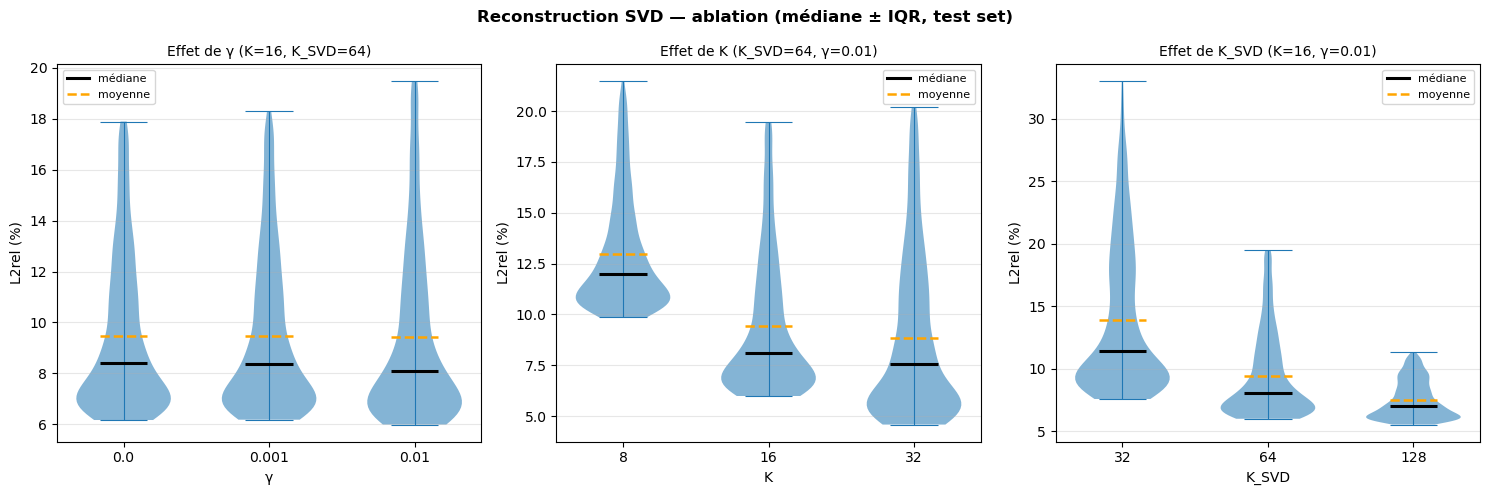

In [15]:
# Base config from svd_bases.pt
K_BASE    = bases_ckpt['K_BASE']
KSVD_BASE = bases_ckpt['K_SVD_BASE']
G_BASE    = bases_ckpt['GAMMA_BASE']

print(f'Base config: K={K_BASE}, K_SVD={KSVD_BASE}, γ={G_BASE}')

def _violin(ax, groups, title, xlabel):
    xs_vals   = sorted(groups.keys())
    datasets  = [list(groups[v]) for v in xs_vals]
    parts = ax.violinplot(datasets, positions=list(range(len(xs_vals))),
                          widths=0.65, showmedians=True, showmeans=True, showextrema=True)
    for pc in parts['bodies']:   pc.set_alpha(0.55)
    parts['cmedians'].set_color('black');  parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');   parts['cmeans'].set_linewidth(1.8)
    parts['cmeans'].set_linestyle('--')
    for k in ('cmaxes', 'cmins', 'cbars'):  parts[k].set_linewidth(0.8)
    ax.set_xticks(range(len(xs_vals)))
    ax.set_xticklabels([str(v) for v in xs_vals])
    ax.set_xlabel(xlabel); ax.set_ylabel('L2rel (%)')
    ax.set_title(title, fontsize=10)
    ax.legend(handles=[
        Line2D([0],[0], color='black',  lw=2.2,            label='médiane'),
        Line2D([0],[0], color='orange', lw=1.8, ls='--',   label='moyenne'),
    ], fontsize=8)
    ax.grid(alpha=0.3, axis='y')

# --- Sweep γ (K=K_BASE, K_SVD=KSVD_BASE) ---
sweep_g = {g: rec_results[_tag(K_BASE, KSVD_BASE, g)]
           for K, k, g in bases_ckpt['configs'] if K == K_BASE and k == KSVD_BASE
           and _tag(K, k, g) in rec_results}

# --- Sweep K (K_SVD=KSVD_BASE, γ=G_BASE) ---
sweep_K = {K: rec_results[_tag(K, KSVD_BASE, G_BASE)]
           for K, k, g in bases_ckpt['configs'] if k == KSVD_BASE and g == G_BASE
           and _tag(K, k, g) in rec_results}

# --- Sweep K_SVD (K=K_BASE, γ=G_BASE) ---
sweep_ksvd = {k: rec_results[_tag(K_BASE, k, G_BASE)]
              for K, k, g in bases_ckpt['configs'] if K == K_BASE and g == G_BASE
              and _tag(K, k, g) in rec_results}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_violin(axes[0], sweep_g,    f'Effet de γ (K={K_BASE}, K_SVD={KSVD_BASE})', 'γ')
_violin(axes[1], sweep_K,    f'Effet de K (K_SVD={KSVD_BASE}, γ={G_BASE})', 'K')
_violin(axes[2], sweep_ksvd, f'Effet de K_SVD (K={K_BASE}, γ={G_BASE})',    'K_SVD')

fig.suptitle('Reconstruction SVD — ablation (médiane ± IQR, test set)', fontweight='bold')
fig.tight_layout()
plt.show()

## 4. Erreur par fréquence Laplace (reconstruction)

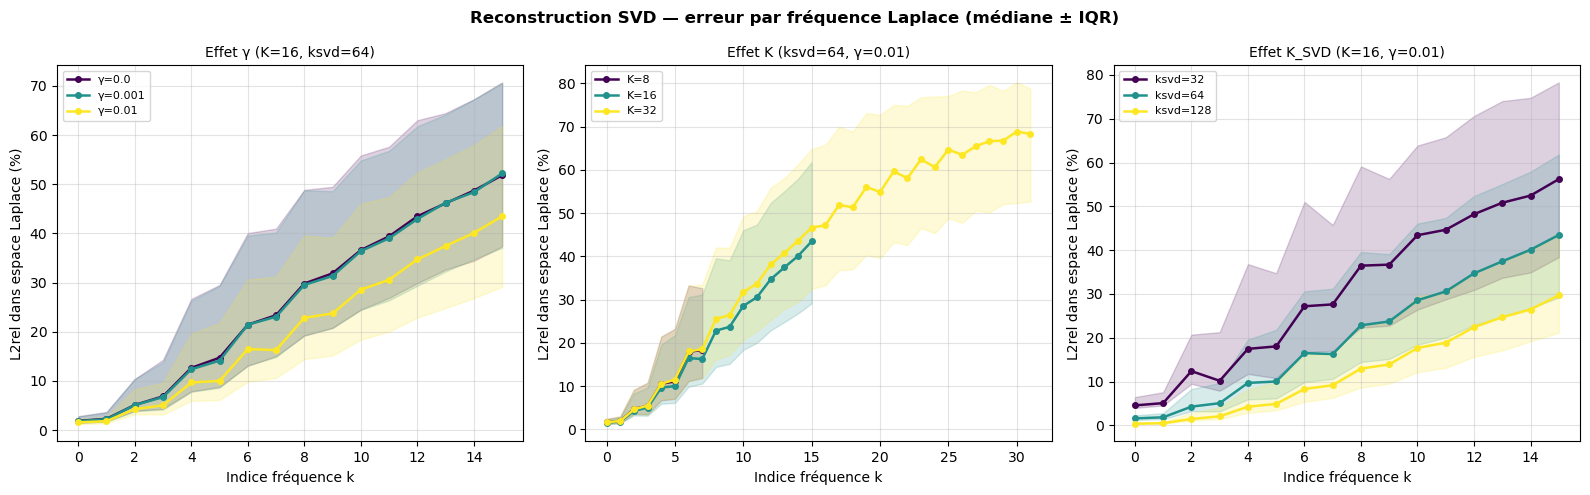

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def _plot_per_freq(ax, sweep, title, var_label, cmap=plt.cm.viridis):
    vals = sorted(sweep.keys())
    norm = plt.Normalize(0, max(len(vals)-1, 1))
    for i, v in enumerate(vals):
        tag = sweep[v]
        if tag not in freq_results: continue
        mat     = freq_results[tag]    # (n_test, K)
        K       = mat.shape[1]
        medians = np.median(mat, axis=0)
        p25     = np.percentile(mat, 25, axis=0)
        p75     = np.percentile(mat, 75, axis=0)
        color   = cmap(norm(i))
        ax.fill_between(range(K), p25, p75, alpha=0.18, color=color)
        ax.plot(range(K), medians, marker='o', ms=4, lw=1.8, color=color,
                label=f'{var_label}={v}')
    ax.set_xlabel('Indice fréquence k')
    ax.set_ylabel('L2rel dans espace Laplace (%)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.35)

sweep_g_freq    = {g: _tag(K_BASE, KSVD_BASE, g)
                   for K,k,g in bases_ckpt['configs'] if K==K_BASE and k==KSVD_BASE}
sweep_K_freq    = {K: _tag(K, KSVD_BASE, G_BASE)
                   for K,k,g in bases_ckpt['configs'] if k==KSVD_BASE and g==G_BASE}
sweep_ksvd_freq = {k: _tag(K_BASE, k, G_BASE)
                   for K,k,g in bases_ckpt['configs'] if K==K_BASE and g==G_BASE}

_plot_per_freq(axes[0], sweep_g_freq,    f'Effet γ (K={K_BASE}, ksvd={KSVD_BASE})', 'γ')
_plot_per_freq(axes[1], sweep_K_freq,    f'Effet K (ksvd={KSVD_BASE}, γ={G_BASE})', 'K')
_plot_per_freq(axes[2], sweep_ksvd_freq, f'Effet K_SVD (K={K_BASE}, γ={G_BASE})',   'ksvd')

fig.suptitle('Reconstruction SVD — erreur par fréquence Laplace (médiane ± IQR)', fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Surrogate SVD — Évaluation (métrique corrigée)

**Fix** : L2rel calculée vs le champ réel U, pas vs la reconstruction SVD.

Pipeline : θ → FreqSurrogate → ĉ(s_k) → dénorm → V_r/V_i → Laplace⁻¹ → Û(t)

In [17]:
def reconstruct_from_coeffs(coeffs, V_r, V_i, laplace, Nt):
    """coeffs: (B, K, 2, K_SVD) → (B, Nt, N²)"""
    U_hat = (
        torch.einsum('bkj,knj->bkn', coeffs[:, :, 0, :], V_r).to(torch.complex64)
        + 1j * torch.einsum('bkj,knj->bkn', coeffs[:, :, 1, :], V_i).to(torch.complex64)
    )
    return laplace.inverse_transform(U_hat, Nt)   # (B, Nt, N²)


def _infer_arch(state_dict):
    """Infer FreqSurrogate hyperparams from a saved state_dict."""
    hidden_dim = state_dict['trunk.0.weight'].shape[0]
    n_trunk    = sum(1 for k, v in state_dict.items()
                     if k.startswith('trunk.') and k.endswith('.weight') and v.dim() == 2)
    head_in    = state_dict['heads.0.0.weight'].shape[1]
    head_dim   = state_dict['heads.0.0.weight'].shape[0]
    freq_L     = (head_in - hidden_dim) // 2
    n_head     = sum(1 for k, v in state_dict.items()
                     if k.startswith('heads.0.') and k.endswith('.weight') and v.dim() == 2)
    return dict(hidden_dim=hidden_dim, head_dim=head_dim,
                n_trunk=n_trunk, n_head=n_head, freq_L=freq_L)


def eval_svd_surrogate(tag, batch_size=32):
    """
    Évalue un surrogate SVD sur le test set.
    Retourne un tableau (n_test,) de L2rel (%) vs champ réel.
    """
    m      = surr_ckpt['models'][tag]
    K      = m['K']
    K_SVD  = m['K_SVD']
    gamma  = m['gamma']
    key_base = f'K{K}_g{gamma:.3f}'

    V_r = surr_ckpt['bases'][key_base]['V_r'][:, :, :K_SVD].to(device)
    V_i = surr_ckpt['bases'][key_base]['V_i'][:, :, :K_SVD].to(device)
    coeff_mean = m['coeff_mean'].to(device)
    coeff_std  = m['coeff_std'].to(device)

    laplace = LearnableLaplace(
        K=K, dt=DT, Nt=NT, gamma_init=gamma,
        learnable=False, alpha_t=ALPHA_T, lam=LAM,
    ).to(device).eval()

    arch = _infer_arch(m['model_state'])
    surrogate = FreqSurrogate(
        theta_dim=3, out_dim=2 * K_SVD, K=K, **arch,
    ).to(device)
    surrogate.load_state_dict(m['model_state'])
    surrogate.eval()

    theta_t = torch.tensor(
        (theta_raw[sorted_test] - theta_mean) / theta_std,
        dtype=torch.float32,
    )

    l2rel_list = []
    with torch.no_grad():
        for start in tqdm(range(0, len(sorted_test), batch_size),
                          desc=tag, leave=False):
            end       = min(start + batch_size, len(sorted_test))
            batch_idx = sorted_test[start:end]
            B         = len(batch_idx)

            th_b     = theta_t[start:end].to(device)
            pred     = surrogate(th_b)
            pred_raw = pred.view(B, K, 2, K_SVD) * coeff_std + coeff_mean

            U_pred = reconstruct_from_coeffs(
                pred_raw, V_r, V_i, laplace, NT
            ).cpu().numpy()   # (B, Nt, N²)

            U_gt = load_u_batch(batch_idx).reshape(B, NT, N * N)

            for j in range(B):
                denom = np.linalg.norm(U_gt[j])
                if denom >= 1e-12:
                    l2rel_list.append(
                        np.linalg.norm(U_pred[j] - U_gt[j]) / denom * 100.0
                    )

            if device == 'cuda': torch.cuda.empty_cache()

    surrogate.cpu(); del surrogate, V_r, V_i, laplace
    if device == 'cuda': torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

In [18]:
def _surr_cache_path(tag):
    return os.path.join(CACHE_DIR, f'surr_{tag}.npz')

def _surr_cache_valid(tag):
    p = _surr_cache_path(tag)
    if not os.path.exists(p): return False
    d = np.load(p, allow_pickle=True)
    return float(d['ckpt_mtime']) == os.path.getmtime(SVD_SURR_PATH)

surr_results = {}   # tag → np.array L2rel (%)

for tag in surr_ckpt['models']:
    if _surr_cache_valid(tag):
        l2 = np.load(_surr_cache_path(tag))['l2rel']
        print(f'[cache]   {tag}')
    else:
        print(f'[compute] {tag}')
        try:
            l2 = eval_svd_surrogate(tag)
            np.savez(_surr_cache_path(tag), l2rel=l2,
                     ckpt_mtime=np.float64(os.path.getmtime(SVD_SURR_PATH)))
        except Exception as e:
            print(f'  ERROR: {e}'); continue

    surr_results[tag] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  p90={np.percentile(l2,90):.2f}%')

print(f'\n({len(surr_results)} surrogates évalués)')

[compute] K8_ksvd64_g0.010


K8_ksvd64_g0.010:   0%|          | 0/51 [00:00<?, ?it/s]

   median=12.41%  mean=13.51%  p90=18.40%
[compute] K16_ksvd64_g0.000


K16_ksvd64_g0.000:   0%|          | 0/51 [00:00<?, ?it/s]

   median=8.96%  mean=10.24%  p90=15.54%
[compute] K16_ksvd32_g0.010


...

   median=8.94%  mean=10.17%  p90=15.36%
[compute] K16_ksvd64_g0.010


K16_ksvd64_g0.010:   0%|          | 0/51 [00:00<?, ?it/s]

   median=8.91%  mean=10.47%  p90=16.34%
[compute] K16_ksvd128_g0.010


K16_ksvd128_g0.010:   0%|          | 0/51 [00:00<?, ?it/s]

   median=11.29%  mean=13.47%  p90=21.74%

(6 surrogates évalués)


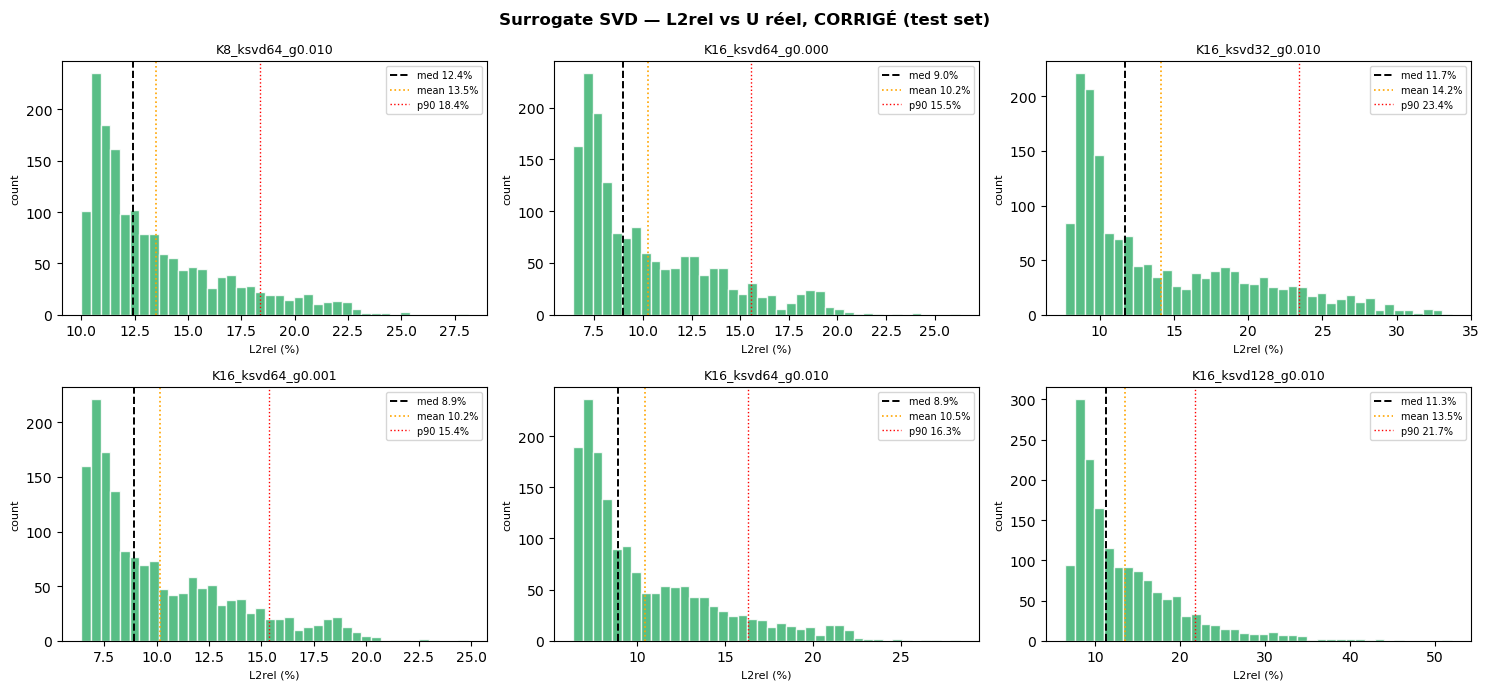

In [19]:
# Histogrammes par config
tags_s = list(surr_results.keys())
ncols  = 3
nrows  = (len(tags_s) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = np.array(axes).flatten()

for ax, tag in zip(axes, tags_s):
    l2     = surr_results[tag]
    median = np.median(l2)
    ax.hist(l2, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
    ax.axvline(median,               color='black',  ls='--', lw=1.4, label=f'med {median:.1f}%')
    ax.axvline(np.mean(l2),          color='orange', ls=':',  lw=1.2, label=f'mean {np.mean(l2):.1f}%')
    ax.axvline(np.percentile(l2,90), color='red',    ls=':',  lw=1.0, label=f'p90 {np.percentile(l2,90):.1f}%')
    ax.set_title(tag, fontsize=9)
    ax.set_xlabel('L2rel (%)', fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.legend(fontsize=7)

for ax in axes[len(tags_s):]:
    ax.set_visible(False)

fig.suptitle('Surrogate SVD — L2rel vs U réel, CORRIGÉ (test set)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Ablation surrogate — effet de K, K_SVD, γ

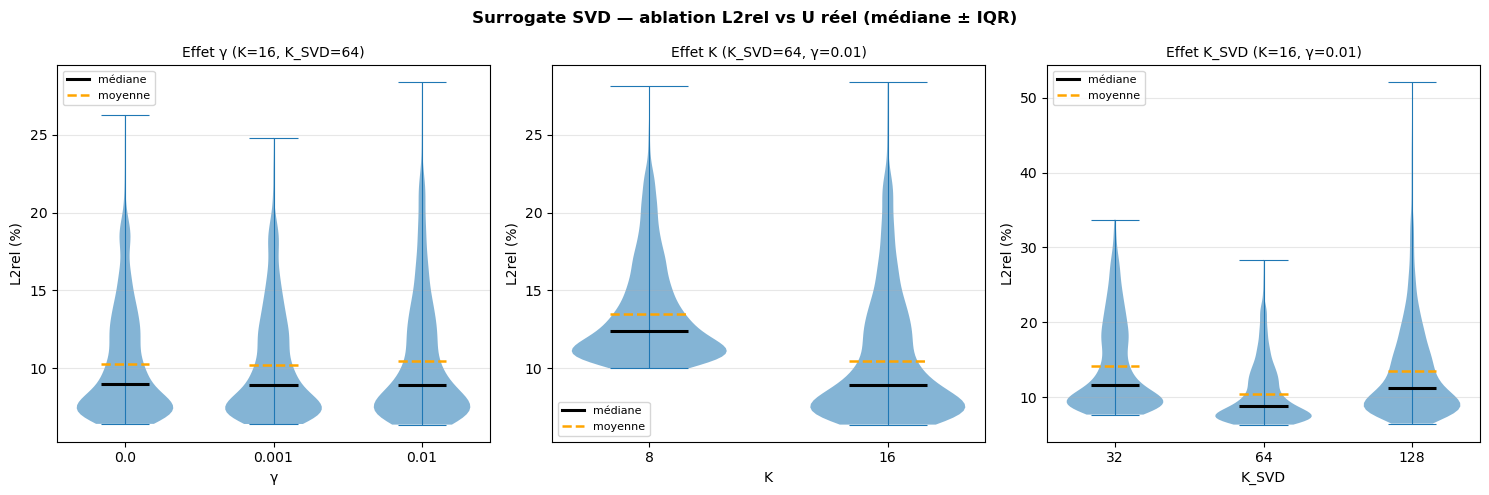

In [20]:
# Métadonnées des configs surrogates
surr_meta = {}  # tag → {K, K_SVD, gamma}
for tag, m in surr_ckpt['models'].items():
    surr_meta[tag] = {'K': m['K'], 'K_SVD': m['K_SVD'], 'gamma': m['gamma']}

def _surr_sweep(var, fixed_dict):
    return {
        meta[var]: surr_results[tag]
        for tag, meta in surr_meta.items()
        if tag in surr_results and all(meta[k] == v for k, v in fixed_dict.items())
    }

sweep_g_s    = _surr_sweep('gamma', {'K': K_BASE, 'K_SVD': KSVD_BASE})
sweep_K_s    = _surr_sweep('K',     {'K_SVD': KSVD_BASE, 'gamma': G_BASE})
sweep_ksvd_s = _surr_sweep('K_SVD', {'K': K_BASE, 'gamma': G_BASE})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
if sweep_g_s:    _violin(axes[0], sweep_g_s,    f'Effet γ (K={K_BASE}, K_SVD={KSVD_BASE})', 'γ')
if sweep_K_s:    _violin(axes[1], sweep_K_s,    f'Effet K (K_SVD={KSVD_BASE}, γ={G_BASE})', 'K')
if sweep_ksvd_s: _violin(axes[2], sweep_ksvd_s, f'Effet K_SVD (K={K_BASE}, γ={G_BASE})',    'K_SVD')

fig.suptitle('Surrogate SVD — ablation L2rel vs U réel (médiane ± IQR)', fontweight='bold')
fig.tight_layout()
plt.show()

## 7. Comparaison reconstruction vs surrogate

Pour chaque config disponible dans les deux, on compare côte à côte le plancher (reconstruction SVD) et le surrogate.

6 configs disponibles dans les deux : ['K16_ksvd128_g0.010', 'K16_ksvd32_g0.010', 'K16_ksvd64_g0.000', 'K16_ksvd64_g0.001', 'K16_ksvd64_g0.010', 'K8_ksvd64_g0.010']


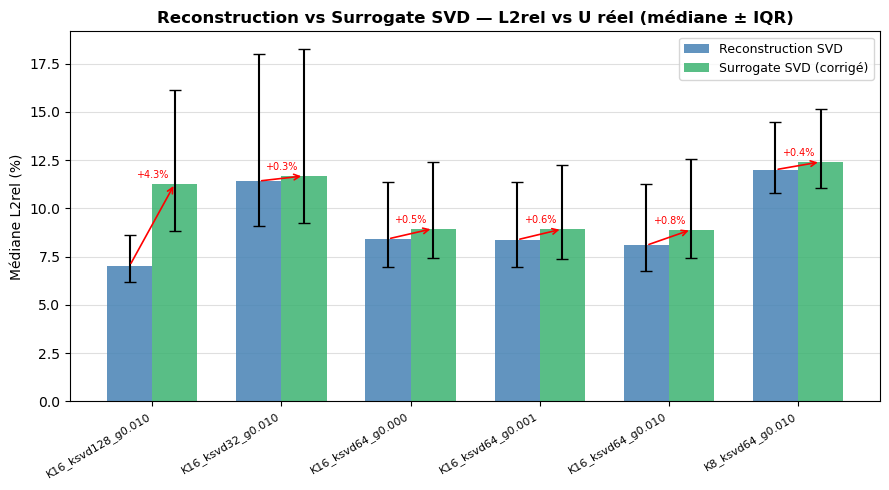


Tag                         Rec med   Surr med       Gap     Gap %
-----------------------------------------------------------------
K16_ksvd64_g0.010             8.09%      8.91%    +0.82%    +10.1%
K16_ksvd64_g0.001             8.38%      8.94%    +0.56%     +6.7%
K16_ksvd64_g0.000             8.42%      8.96%    +0.54%     +6.4%
K16_ksvd128_g0.010            7.04%     11.29%    +4.26%    +60.5%
K16_ksvd32_g0.010            11.42%     11.69%    +0.27%     +2.3%
K8_ksvd64_g0.010             12.01%     12.41%    +0.41%     +3.4%


In [21]:
common_tags = sorted(set(rec_results) & set(surr_results))
print(f'{len(common_tags)} configs disponibles dans les deux : {common_tags}')

if common_tags:
    x  = np.arange(len(common_tags))
    w  = 0.35

    med_rec  = [np.median(rec_results[t])  for t in common_tags]
    med_surr = [np.median(surr_results[t]) for t in common_tags]
    p25_rec  = [np.percentile(rec_results[t],  25) for t in common_tags]
    p75_rec  = [np.percentile(rec_results[t],  75) for t in common_tags]
    p25_surr = [np.percentile(surr_results[t], 25) for t in common_tags]
    p75_surr = [np.percentile(surr_results[t], 75) for t in common_tags]

    fig, ax = plt.subplots(figsize=(max(9, len(common_tags)*1.5), 5))

    bars_r = ax.bar(x - w/2, med_rec,  w, label='Reconstruction SVD', color='steelblue', alpha=0.85, zorder=2)
    bars_s = ax.bar(x + w/2, med_surr, w, label='Surrogate SVD (corrigé)', color='mediumseagreen', alpha=0.85, zorder=2)

    ax.errorbar(x - w/2, med_rec,
                yerr=[[mr-p25 for mr,p25 in zip(med_rec,p25_rec)],
                      [p75-mr for mr,p75 in zip(med_rec,p75_rec)]],
                fmt='none', color='black', capsize=4, lw=1.5, zorder=3)
    ax.errorbar(x + w/2, med_surr,
                yerr=[[mr-p25 for mr,p25 in zip(med_surr,p25_surr)],
                      [p75-mr for mr,p75 in zip(med_surr,p75_surr)]],
                fmt='none', color='black', capsize=4, lw=1.5, zorder=3)

    # Flèche montrant le gap
    for xi, mr, ms in zip(x, med_rec, med_surr):
        gap = ms - mr
        color = 'red' if gap > 0 else 'green'
        ax.annotate('', xy=(xi+w/2, ms), xytext=(xi-w/2, mr),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
        ax.text(xi, max(mr, ms) + 0.3, f'+{gap:.1f}%' if gap > 0 else f'{gap:.1f}%',
                ha='center', fontsize=7, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(common_tags, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Médiane L2rel (%)')
    ax.set_title('Reconstruction vs Surrogate SVD — L2rel vs U réel (médiane ± IQR)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4, zorder=0)
    fig.tight_layout()
    plt.show()

    # Table résumé
    print(f'\n{"Tag":<25}  {"Rec med":>8}  {"Surr med":>9}  {"Gap":>8}  {"Gap %":>8}')
    print('-' * 65)
    for tag in sorted(common_tags, key=lambda t: np.median(surr_results[t])):
        mr  = np.median(rec_results[tag])
        ms  = np.median(surr_results[tag])
        gap = ms - mr
        print(f'{tag:<25}  {mr:>7.2f}%  {ms:>8.2f}%  {gap:>+7.2f}%  {gap/mr*100:>+7.1f}%')

## 8. Benchmark inference — latence et débit

In [22]:
N_BENCH      = 200
N_WARMUP     = 10
N_RUNS       = 50
BATCH_SIZES  = [1, 8, 32, 128]

bench_theta_raw = theta_raw[sorted_test[:N_BENCH]]   # (N_BENCH, 3)

def _time_gpu(fn, n_warmup, n_runs):
    for _ in range(n_warmup): fn()
    torch.cuda.synchronize()
    ev_s = torch.cuda.Event(enable_timing=True)
    ev_e = torch.cuda.Event(enable_timing=True)
    ms = []
    for _ in range(n_runs):
        ev_s.record(); fn(); ev_e.record()
        torch.cuda.synchronize()
        ms.append(ev_s.elapsed_time(ev_e))
    return np.array(ms)

def _time_cpu(fn, n_warmup, n_runs):
    for _ in range(n_warmup): fn()
    ms = []
    for _ in range(n_runs):
        t0 = time.perf_counter(); fn()
        ms.append((time.perf_counter() - t0) * 1e3)
    return np.array(ms)

_time_fn = _time_gpu if device == 'cuda' else _time_cpu

bench = {}

for tag in tqdm(list(surr_ckpt['models'].keys()), desc='Benchmark latence'):
    m        = surr_ckpt['models'][tag]
    K        = m['K']
    K_SVD    = m['K_SVD']
    gamma    = m['gamma']
    key_base = f'K{K}_g{gamma:.3f}'

    V_r        = surr_ckpt['bases'][key_base]['V_r'][:, :, :K_SVD].to(device)
    V_i        = surr_ckpt['bases'][key_base]['V_i'][:, :, :K_SVD].to(device)
    coeff_mean = m['coeff_mean'].to(device)
    coeff_std  = m['coeff_std'].to(device)
    laplace    = LearnableLaplace(K=K, dt=DT, Nt=NT, gamma_init=gamma,
                                  learnable=False, alpha_t=ALPHA_T, lam=LAM).to(device).eval()

    arch      = _infer_arch(m['model_state'])
    surrogate = FreqSurrogate(theta_dim=3, out_dim=2*K_SVD, K=K, **arch).to(device).eval()
    surrogate.load_state_dict(m['model_state'])

    th1 = torch.tensor((bench_theta_raw[:1] - theta_mean) / theta_std,
                       dtype=torch.float32, device=device)

    def _forward_bs1():
        with torch.no_grad():
            pred = surrogate(th1)
            pred_raw = pred.view(1, K, 2, K_SVD) * coeff_std + coeff_mean
            reconstruct_from_coeffs(pred_raw, V_r, V_i, laplace, NT)

    lat_ms = _time_fn(_forward_bs1, N_WARMUP, N_RUNS)

    tput_dict = {}
    for bs in BATCH_SIZES:
        th_bs = torch.tensor((bench_theta_raw[:bs] - theta_mean) / theta_std,
                             dtype=torch.float32, device=device)
        def _forward_bs(th=th_bs, b=bs):
            with torch.no_grad():
                pred = surrogate(th)
                pred_raw = pred.view(b, K, 2, K_SVD) * coeff_std + coeff_mean
                reconstruct_from_coeffs(pred_raw, V_r, V_i, laplace, NT)
        try:
            t_ms = _time_fn(_forward_bs, N_WARMUP, min(N_RUNS, 20))
            tput_dict[bs] = bs / (np.median(t_ms) * 1e-3)
        except Exception:
            tput_dict[bs] = 0

    bench[tag] = dict(lat_med=np.median(lat_ms), lat_std=np.std(lat_ms),
                      tput=tput_dict, K=K, K_SVD=K_SVD, gamma=gamma)

    print(f'{tag:<25}  lat={np.median(lat_ms):.1f}±{np.std(lat_ms):.1f} ms  '
          + '  '.join(f'tput@bs{bs}={v:.0f} s/s' for bs, v in tput_dict.items()))

    for obj in [surrogate, V_r, V_i, laplace, coeff_mean, coeff_std, th1]:
        try: obj.cpu()
        except: pass
    del surrogate, V_r, V_i, laplace, coeff_mean, coeff_std, th1
    if device == 'cuda': torch.cuda.empty_cache()
    gc.collect()

print('\nDone.')

Benchmark latence:   0%|          | 0/6 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
if bench:
    tags_b = sorted(bench, key=lambda t: bench[t]['lat_med'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(tags_b))
    col = plt.cm.viridis(np.linspace(0, 1, len(tags_b)))

    # Latence bs=1
    lats = [bench[t]['lat_med'] for t in tags_b]
    stds = [bench[t]['lat_std'] for t in tags_b]
    axes[0].bar(x, lats, color=col, alpha=0.85, zorder=2)
    axes[0].errorbar(x, lats, yerr=stds, fmt='none', color='black', capsize=4, lw=1.5, zorder=3)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(tags_b, rotation=35, ha='right', fontsize=8)
    axes[0].set_ylabel('Latence (ms / sample)')
    axes[0].set_title('Latence bs=1 (CUDA Events)', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.4)

    # Débit vs K_SVD
    bs_plot = 32
    for i, t in enumerate(tags_b):
        tput = bench[t]['tput'].get(bs_plot, 0)
        axes[1].scatter(bench[t]['K_SVD'], tput, s=80, color=col[i],
                        zorder=3, label=t)
        axes[1].annotate(t, (bench[t]['K_SVD'], tput),
                         fontsize=6, textcoords='offset points', xytext=(4, 2))
    axes[1].set_xlabel('K_SVD')
    axes[1].set_ylabel(f'Débit (samples/s, bs={bs_plot})')
    axes[1].set_title(f'Débit vs K_SVD (bs={bs_plot})', fontweight='bold')
    axes[1].grid(alpha=0.3)

    gpu_name = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
    fig.suptitle(f'Surrogate SVD — benchmark inference ({gpu_name})', fontweight='bold')
    fig.tight_layout()
    plt.show()

    # Table résumé
    print(f'\n{"Tag":<25}  {"lat (ms)":>10}  ' + '  '.join(f'bs={bs}':>10 for bs in BATCH_SIZES))
    print('-' * (30 + 12 * len(BATCH_SIZES)))
    for t in tags_b:
        b = bench[t]
        tput_str = '  '.join(f'{b["tput"].get(bs,0):>9.0f}' for bs in BATCH_SIZES)
        print(f'{t:<25}  {b["lat_med"]:>7.1f}±{b["lat_std"]:>4.1f}  {tput_str}')

## 9. Résumé global — tableau comparatif

In [ ]:
all_tags = sorted(set(rec_results) | set(surr_results))

print(f'{"Config":<25}  {"Rec med":>8}  {"Rec p90":>8}  {"Surr med":>9}  {"Surr p90":>9}  {"Gap":>7}  {"Lat (ms)":>9}')
print('─' * 90)
for tag in sorted(all_tags, key=lambda t: (
        np.median(surr_results.get(t, [np.inf])),
        np.median(rec_results.get(t, [np.inf])))):
    mr  = f"{np.median(rec_results[tag]):.2f}%"  if tag in rec_results  else '  —  '
    mp  = f"{np.percentile(rec_results[tag],90):.2f}%" if tag in rec_results else '  —  '
    ms  = f"{np.median(surr_results[tag]):.2f}%" if tag in surr_results else '  —  '
    msp = f"{np.percentile(surr_results[tag],90):.2f}%" if tag in surr_results else '  —  '
    gap = ''
    if tag in rec_results and tag in surr_results:
        g = np.median(surr_results[tag]) - np.median(rec_results[tag])
        gap = f'{g:+.2f}%'
    lat = f"{bench[tag]['lat_med']:.1f}" if tag in bench else '  —  '
    print(f'{tag:<25}  {mr:>8}  {mp:>8}  {ms:>9}  {msp:>9}  {gap:>7}  {lat:>9}')